In [ ]:
## need to activate nm_swe environment and specify path to kernel 
# conda env create -f setup/environment.yml
# conda activate nm_swe
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rasterio as rio
import rioxarray as rxr
import matplotlib.pyplot as plt
from glob import glob
import re
import matplotlib.colors as mcolors

## Set date for plotting

In [6]:
## set date
date = "20230216"

## Load raster and prepare for plotting

the minimum raster value is:  0.0
the maximum raster value is:  32767.0


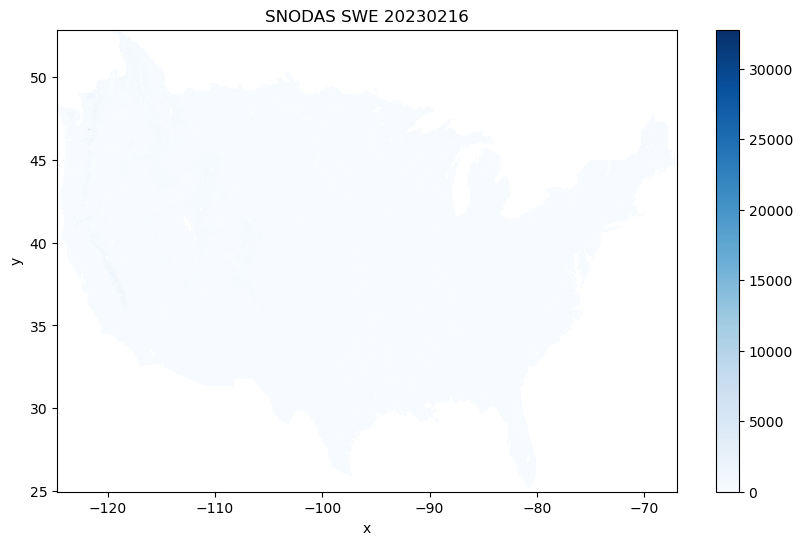

the minimum raster value is:  0.0
the maximum raster value is:  30.62955


In [9]:
## read raster file
snodas_file = "../data/SNODAS/SNODAS_SWE_" + date + ".tif"

data = rxr.open_rasterio(snodas_file, masked = True).squeeze()
data.shape
data.rio.crs
data.rio.nodata

## get min and max values
print("the minimum raster value is: ", np.nanmin(data.values))
print("the maximum raster value is: ", np.nanmax(data.values))

# Plot the raster data
f, ax = plt.subplots(figsize=(10, 6))
data.plot(cmap="Blues",
                 ax=ax)
ax.set_title("SNODAS SWE " + date)
#ax.set_axis_off()
plt.show()

## read shapefiles
OSE = gpd.read_file("../data/Shapefiles/OSE_Basin_Designations/SubBasins_Dissolve.shp")
OSE = OSE.to_crs(4326)
OSE.crs
HUC8 = gpd.read_file("../data/Shapefiles/WBDHU8_RG/WBDHU8_RG.shp")
HUC6 = gpd.read_file("../data/Shapefiles/WBDHU6_RG/WBDHU6_RG.shp")

## check if crs are equal
OSE.crs
HUC8.crs
HUC6.crs
OSE.crs == HUC8.crs == HUC6.crs == data.rio.crs

## select HUC6 polygons of interest
list(HUC6.columns.values)
HUC6['Name'].unique()

## select first 3 rows
HUC6_polys = ['Rio Grande Headwaters', 'Upper Rio Grande',
       'Rio Grande-Elephant Butte']
HUC6 = HUC6[HUC6['Name'].isin(HUC6_polys)]
#HUC6 = HUC6.head(3)
HUC6['Name'].unique()

## select OSE polygons of interest
OSE['SubBasin'].unique()
OSE = OSE.loc[OSE['SubBasin'] != 'San Juan River Basin']
OSE['SubBasin'].unique()

## clip raster to HUC6 extent
bbox = HUC6.total_bounds
bbox = bbox + np.array([-1,-0.5,1,0.5])
clipped_data = data.rio.clip_box(*bbox) / 1000 * 3.2808 * 12 # convert to inches

## get min and max values
print("the minimum raster value is: ", np.nanmin(clipped_data.values))
print("the maximum raster value is: ", np.nanmax(clipped_data.values))

# Plot the raster data
clipped_data.attrs["long_name"] = "SWE [in]"

## manually assign OSE colors
custom_colors = ["green", "orange", "red", "blue"]
custom_cmap = mcolors.ListedColormap(custom_colors)

## Plot SNODAS raster with HUC6 and OSE polygons

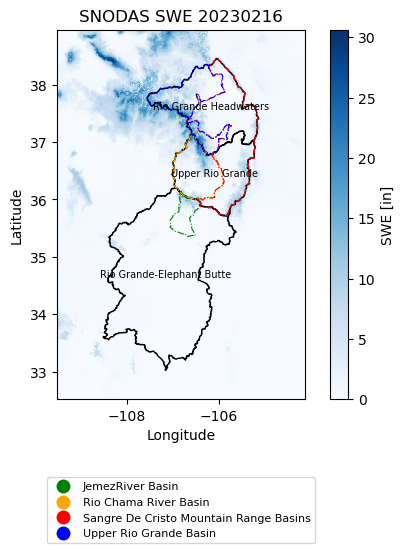

In [10]:


## plot
f, ax = plt.subplots()
clipped_data.plot(cmap="Blues",
                 ax=ax)
#plt.colorbar(label='SWE (mm)')
HUC6.plot(color='None',
                    edgecolor='black',
                    linewidth=1,
                    ax=ax)
## add polygon labels
for idx, row in HUC6.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row["Name"],
            fontsize=7, color="black", ha="center", va="center")

'''
## plot with filled polygons
OSE.plot(column='SubBasin',  
         cmap='Reds',
         edgecolor='None',
         linewidth=0.5,
         legend=True,
         ax=ax,
         alpha = 0.5)
'''
## plot with outlined polygons
## dotted lines so overlapping boundaries are visible

OSE.plot(column='SubBasin',  
         #cmap='turbo',
         cmap = custom_cmap,
         facecolor='none', 
         edgecolor=None, 
         linewidth=0.8,  
         legend=True,
         legend_kwds={'fontsize': 8},
         ax=ax,
         alpha=1,
         linestyle="-.")



ax.set_title("SNODAS SWE " + date)
ax.set_axis_on()
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
#ax.set_axis_off()
legend = ax.get_legend()
if legend:
    legend.set_bbox_to_anchor((0.5, -0.3)) # move legend below plot
    legend.set_loc("center")
    

plt.show()